In [1]:
import numpy as np
import csv
import os
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

In [30]:
# get data from csv files and convert to numpy array of form (nTrials, nEMGChannels, nTrialLength)
# For a start, consider nTrialLength of 200 time steps of EMG (100ms)

# For y data, just use ankle angle at the end of the trial for now
# Thus array is of form (nTrials, 1)

#note: we don't actually know how many trials we have yet .. for now assume 300
# and chop off any unused at the end
# (come up with something more elegant later)
nTrials = 5000
nTrialLen = 20
nEMGChannels = 64
factor_EMGlen2AnkleLen = 20 # sampling rate of emg is 20x higher than ankle data

X_data = np.zeros((nTrials,nEMGChannels, nTrialLen))
Y_data = np.zeros((nTrials, 2))
iTrial = 0

dataDir = "/content/"

# add for loop to go through all emg files for this subj
for fileName in os.listdir(dataDir):
  if fileName.startswith("EMG_Proc"):
    # load file from processed emg files
    emgFileData = np.loadtxt(dataDir + fileName, dtype=float, delimiter=",")
    # get data from corresponding ankle file
    ankleFileName = "Ankle" + fileName[8:]
    ankleFileData = np.loadtxt(dataDir + ankleFileName, dtype=float, delimiter=",")

    # iterate through EMG file and pull out non-overlapping segments of length
    # nTrialLen and add them to X_data
    # also pull out ankle angle for matching time step and add to Y_data
    nFileLen = emgFileData.shape[0]
    iTrialStart = 0
    while (iTrialStart + nTrialLen) < nFileLen:
      X_data[iTrial, :, :] = np.transpose(emgFileData[iTrialStart:iTrialStart+nTrialLen, :])
      Y_data[iTrial,:] = ankleFileData[int((iTrialStart+nTrialLen) / factor_EMGlen2AnkleLen),:]
      iTrial += 1
      iTrialStart += nTrialLen

In [31]:
nTrials = iTrial
# now we know how many trials there are .. remove unused trials from data array
X_data = X_data[:nTrials, :, :]
Y_data = Y_data[:nTrials, :]

In [32]:
# create test/train split for this data
X_train, X_test, Y_train, Y_test = train_test_split(
    X_data, Y_data, test_size=0.2, random_state=13)

In [33]:
# Reshape x datasets to feed into model
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1], X_train.shape[2])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1], X_test.shape[2])

In [34]:
print(Y_train.shape)

(2979, 2)


# Define Model

For now, just make a super simple CNN to see if we can train on this data

In [35]:
keras.backend.set_image_data_format('channels_first')

In [36]:
# Update 25-04-16
# This are the model parameters used in the original paper
# For us, these values probably need to be changed because we have some many
# more EMG channels. This model is huge for what we are trying to do.

input_shape = (1, nEMGChannels, nTrialLen)

model = keras.Sequential()
model.add(keras.Input(shape=input_shape))

model.add(keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Flatten())
model.add(keras.layers.Dropout(0.3))


model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dropout(0.3))


model.add(keras.layers.Dense(2, activation='linear'))


In [37]:
model.summary()
model.compile(loss=keras.losses.MeanSquaredError, optimizer= keras.optimizers.Adam(learning_rate=0.001), metrics=["mean_squared_error"])

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 64, 20)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128, 64, 20)    │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 163840)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 163840)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │    20,971,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,990,802 (80.07 MB)

 Trainable params: 20,990,250 (80.07 MB)

 Non-trainable params: 552 (2.16 KB)

In [38]:
hist = model.fit(X_train, Y_train, batch_size=64, shuffle=True, epochs=300, validation_split=0.125)

Epoch 1/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 15s 196ms/step - loss: 590.1362 - mean_squared_error: 590.1362 - val_loss: 349.1156 - val_mean_squared_error: 349.1156
Epoch 2/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 431.6461 - mean_squared_error: 431.6461 - val_loss: 398.8508 - val_mean_squared_error: 398.8508
Epoch 3/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 372.1710 - mean_squared_error: 372.1710 - val_loss: 330.6690 - val_mean_squared_error: 330.6690
Epoch 4/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 335.3778 - mean_squared_error: 335.3778 - val_loss: 295.3667 - val_mean_squared_error: 295.3667
Epoch 5/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 287.1555 - mean_squared_error: 287.1555 - val_loss: 241.5470 - val_mean_squared_error: 241.5470
Epoch 6/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 228.9830 - mean_squared_error: 228.9830 - val_loss: 211.1112 - val_mean_squared_error: 211.1112
Epoch 7/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 15

In [39]:
y_pred = model.predict(X_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


R2 score for angle: 0.6800155699222348


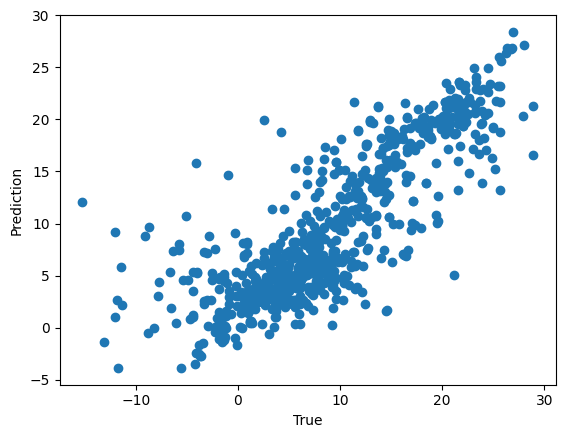

In [40]:
plt.scatter(Y_test[:,0], y_pred[:,0])
plt.ylabel("Prediction")
plt.xlabel("True")
print("R2 score for angle: " + str(r2_score(Y_test[:,0], y_pred[:,0])))

R2 score for torque: 0.6996811241511195


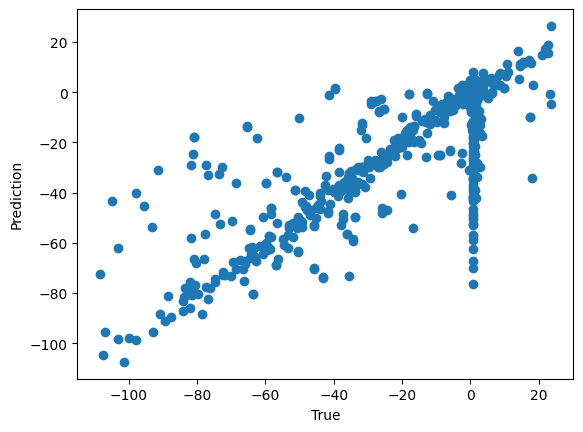

In [41]:
plt.scatter(Y_test[:,1], y_pred[:,1])
plt.ylabel("Prediction")
plt.xlabel("True")
print("R2 score for torque: " + str(r2_score(Y_test[:,1], y_pred[:,1])))

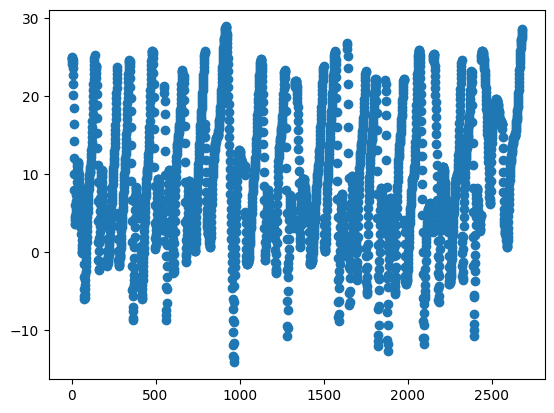

In [ ]:
plt.scatter(np.arange(nTrials), Y_data)